# Step-by-Step Model Forward Pass (Input Flow Through `BertForDiffusion`)

This notebook shows exactly how a preprocessed batch flows through `BertForDiffusion.forward`.

It follows the style of `visualize_metrics_step_by_step.ipynb`: clear numbered sections, intermediate tensors, and annotated checks.

What you will see:

1. Build one real training-style batch (`NoisedDataset` + `DataLoader`)
2. Instantiate model from config
3. Recreate `forward` manually, line by line
4. Confirm manual reconstruction matches `model.forward(...)`
5. Draw a model architecture diagram (component stack + tensor flow)



In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader
from transformers.models.bert import configuration_bert

import ringer
from ringer import data
from ringer.data import noised
from ringer.models import bert_for_diffusion

torch.manual_seed(0)
np.random.seed(0)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print(f"CONFIG_DIR: {ringer.CONFIG_DIR}")
print(f"DATA_DIR:   {ringer.DATA_DIR}")



/home/phamnh/miniforge3/envs/ringer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CONFIG_DIR: /mnt/HDD1/Codes/ringer/configs
DATA_DIR:   /mnt/HDD1/Codes/ringer/data


## 1) Load config and build one training-style batch

We use `configs/minimal_conditional.json` so this runs quickly while still following the exact training preprocessing path.

**Annotated checks:**
- `corrupted`, `known_noise` are `[B, L, F]`
- `t` is `[B, 1]`
- masks/IDs are present and aligned with sequence length



In [2]:
config_path = Path("configs/conditional_dummy.json")
with open(config_path, "r") as f:
    cfg = json.load(f)

print("Config file:", config_path)
print("internal_coordinates_definitions:", cfg["internal_coordinates_definitions"])
print("timesteps:", cfg["timesteps"])
print("position_embedding_type:", cfg["position_embedding_type"])
print("time_encoding:", cfg["time_encoding"])

# Resolve data dir exactly like training code
data_dir = Path(cfg["data_dir"])
if not data_dir.exists():
    data_dir = ringer.DATA_DIR / data_dir

clean_dset_class = data.DATASET_CLASSES[cfg["internal_coordinates_definitions"]]
clean_dset = clean_dset_class(
    data_dir=data_dir,
    split="train",
    split_sizes=cfg["split_sizes"],
    use_atom_features=cfg["use_atom_features"],
    fingerprint_radius=cfg.get("atom_feature_fingerprint_radius", 3),
    fingerprint_size=cfg.get("atom_feature_fingerprint_size", 32),
    num_conf=cfg["max_conf"],
    all_confs_in_test=True,
    zero_center=True,
    use_cache=True,
    num_proc=1,
)

noised_dset = noised.NoisedDataset(
    dset=clean_dset,
    dset_key="angles",
    timesteps=cfg["timesteps"],
    exhaustive_t=False,
    beta_schedule=cfg["variance_schedule"],
    nonangular_variance=1.0,
    angular_variance=cfg["variance_scale"],
    mask_noise=False,
    mask_noise_for_features=None,
)

loader = DataLoader(noised_dset, batch_size=4, shuffle=False, num_workers=0)
batch = next(iter(loader))

print("\nBatch keys:", list(batch.keys()))
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"{k:28s} shape={tuple(v.shape)} dtype={v.dtype}")

seq_len_0 = int(batch["attn_mask"][0].sum().item())
print("\nExample sample 0 true sequence length:", seq_len_0)
print("Example sample 0 timestep t:", int(batch["t"][0].item()))



Config file: configs/conditional_dummy.json
internal_coordinates_definitions: angles-sidechains
timesteps: 20
position_embedding_type: cyclic_relative_key
time_encoding: gaussian_fourier

Batch keys: ['angles', 'attn_mask', 'feat_mask', 'position_ids', 'atom_ids', 'lengths', 'weights', 'atom_features', 'corrupted', 't', 'known_noise', 'sqrt_alphas_cumprod_t', 'sqrt_one_minus_alphas_cumprod_t']
angles                       shape=(4, 18, 12) dtype=torch.float32
attn_mask                    shape=(4, 18) dtype=torch.float32
feat_mask                    shape=(4, 18, 12) dtype=torch.float32
position_ids                 shape=(4, 18) dtype=torch.int64
atom_ids                     shape=(4, 18) dtype=torch.int64
lengths                      shape=(4,) dtype=torch.int64
weights                      shape=(4, 12) dtype=torch.float32
atom_features                shape=(4, 18, 178) dtype=torch.float32
corrupted                    shape=(4, 18, 12) dtype=torch.float32
t                           

/mnt/HDD1/Codes/ringer/ringer/utils/utils.py:109: RuntimeWarning: Mean of empty slice
  retval = np.arctan2(np.nanmean(sin_x, axis=axis), np.nanmean(cos_x, axis=axis))


In [3]:
clean_dset[0]

{'angles': tensor([[ 0.1171, -1.9103,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1910,  1.6187, -0.0024,  0.0000,  0.0000,  0.0000,  0.0000,  0.2043,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0216, -0.4225,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.1133,  1.6877,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1806, -1.8316, -0.0105, -0.0107,  0.0000,  0.0000,  0.0000, -0.4080,
          -1.9970,  0.0000,  0.0000,  0.0000],
         [-0.0181,  0.2234,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.1029, -1.8938,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1774,  1.5449,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
     

In [4]:
a = noised_dset[0]

In [25]:
for k, v in a.items():
    if torch.is_tensor(v):
        print(f"{k:28s} shape={tuple(v.shape)} dtype={v.dtype}")

angles                       shape=(18, 12) dtype=torch.float32
attn_mask                    shape=(18,) dtype=torch.float32
feat_mask                    shape=(18, 12) dtype=torch.float32
position_ids                 shape=(18,) dtype=torch.int64
atom_ids                     shape=(18,) dtype=torch.int64
lengths                      shape=() dtype=torch.int64
weights                      shape=(12,) dtype=torch.float32
atom_features                shape=(18, 178) dtype=torch.float32
corrupted                    shape=(18, 12) dtype=torch.float32
t                            shape=(1,) dtype=torch.int64
known_noise                  shape=(18, 12) dtype=torch.float32
sqrt_alphas_cumprod_t        shape=() dtype=torch.float32
sqrt_one_minus_alphas_cumprod_t shape=() dtype=torch.float32


In [6]:
a

{'angles': tensor([[ 0.1171, -1.9103,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1910,  1.6187, -0.0024,  0.0000,  0.0000,  0.0000,  0.0000,  0.2043,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0216, -0.4225,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.1133,  1.6877,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1806, -1.8316, -0.0105, -0.0107,  0.0000,  0.0000,  0.0000, -0.4080,
          -1.9970,  0.0000,  0.0000,  0.0000],
         [-0.0181,  0.2234,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.1029, -1.8938,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000],
         [-0.1774,  1.5449,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
     

## 2) Instantiate `BertForDiffusion` with the same setup pattern as training

This mirrors the model construction in `ringer/train.py`.

**Annotated checks:**
- input feature count `F`
- atom feature dimension
- effective hidden size (expanded when atom features are concatenated)



In [7]:
sample_item = noised_dset[0]
model_n_inputs = sample_item["corrupted"].shape[-1]
atom_feature_size = sample_item["atom_features"].shape[-1] if "atom_features" in sample_item else None

bert_cfg = configuration_bert.BertConfig(
    max_position_embeddings=noised_dset.pad,
    num_attention_heads=cfg["num_heads"],
    hidden_size=cfg["hidden_size"],
    intermediate_size=cfg["intermediate_size"],
    num_hidden_layers=cfg["num_hidden_layers"],
    position_embedding_type=cfg["position_embedding_type"],
    hidden_dropout_prob=cfg["dropout_p"],
    attention_probs_dropout_prob=cfg["dropout_p"],
    use_cache=False,
)

model = bert_for_diffusion.BertForDiffusion(
    config=bert_cfg,
    ft_is_angular=noised_dset.feature_is_angular,
    ft_names=noised_dset.feature_names,
    time_encoding=cfg["time_encoding"],
    decoder=cfg["decoder"],
    atom_feature_size=atom_feature_size,
    atom_feature_embed_size=cfg["atom_feature_embed_size"],
    lr=cfg["lr"],
    loss=cfg["loss"],
    use_feat_mask=cfg.get("use_feat_mask", True),
    l2=cfg["l2_norm"],
    l1=cfg["l1_norm"],
    circle_reg=cfg["circle_reg"],
    epochs=cfg["max_epochs"],
    warmup_epochs=cfg["warmup_epochs"],
    lr_scheduler=cfg["lr_scheduler"],
)
model.eval()  # disable dropout for deterministic comparisons

print("Number of input IC features (F):", model_n_inputs)
print("Atom feature size:", atom_feature_size)
print("Configured hidden_size in config:", cfg["hidden_size"])
print("Model config hidden_size after atom concat expansion:", model.config.hidden_size)
print("use_atom_embeddings:", model.use_atom_embeddings)
print("position_embedding_type:", model.embeddings.position_embedding_type)
print("time embedding module:", model.time_embed.__class__.__name__)
print("decoder module:", model.token_decoder.__class__.__name__)



Using time embedding: GaussianFourierProjection()
Using loss: [functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, beta=0.3141592653589793), functools.partial(<function radian_smooth_l1_loss at 0x774902fe83a0>, bet

Number of input IC features (F): 12
Atom feature size: 178
Configured hidden_size in config: 256
Model config hidden_size after atom concat expansion: 384
use_atom_embeddings: False
position_embedding_type: cyclic_relative_key
time embedding module: GaussianFourierProjection
decoder module: AnglesPredictor


## 3) Prepare forward inputs and summarize tensor shapes

This is what `BertForDiffusion.forward(...)` receives from the training step.



In [8]:
inputs = batch["corrupted"]
timestep = batch["t"]
attention_mask = batch["attn_mask"]
position_ids = batch["position_ids"]
atom_ids = batch["atom_ids"]
atom_features = batch.get("atom_features")


def tensor_summary(name, t):
    t_float = t.detach().float()
    return {
        "name": name,
        "shape": tuple(t.shape),
        "dtype": str(t.dtype),
        "min": float(t_float.min().item()),
        "max": float(t_float.max().item()),
        "mean": float(t_float.mean().item()),
    }

summaries = [
    tensor_summary("inputs (corrupted)", inputs),
    tensor_summary("timestep", timestep),
    tensor_summary("attention_mask", attention_mask),
    tensor_summary("position_ids", position_ids),
    tensor_summary("atom_ids", atom_ids),
]
if atom_features is not None:
    summaries.append(tensor_summary("atom_features", atom_features))

display(pd.DataFrame(summaries))



,name,shape,dtype,min,max,mean
0,inputs (corrupted),"(4, 18, 12)",torch.float32,-3.046955,2.855425,0.020555
1,timestep,"(4, 1)",torch.int64,1.000000,16.000000,9.000000
2,attention_mask,"(4, 18)",torch.float32,0.000000,1.000000,0.666667
3,position_ids,"(4, 18)",torch.int64,0.000000,17.000000,8.500000
4,atom_ids,"(4, 18)",torch.int64,0.000000,2.000000,0.666667
5,atom_features,"(4, 18, 178)",torch.float32,-1.000000,4.000000,0.058677


## 4) Recreate `forward`: position IDs and expanded attention mask

This reproduces the first logic block in `BertForDiffusionBase.forward`.

**Annotated checks:**
- auto-generated `position_ids` shape is `[B, L]`
- expanded attention mask shape is `[B, 1, 1, L]`



In [9]:
input_shape = inputs.size()
batch_size, seq_length, _ = input_shape
print("input_shape:", tuple(input_shape))
print("batch_size:", batch_size, "seq_length:", seq_length)

if position_ids is None:
    position_ids_manual = torch.arange(seq_length).expand(batch_size, -1).type_as(timestep)
else:
    position_ids_manual = position_ids

extended_attention_mask = attention_mask[:, None, None, :]
extended_attention_mask = extended_attention_mask.type_as(attention_mask)
extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0

print("position_ids_manual shape:", tuple(position_ids_manual.shape))
print("extended_attention_mask shape:", tuple(extended_attention_mask.shape))

# Show one row for annotation
print("\nSample 0 attention_mask[:20]:", attention_mask[0, :20].tolist())
print("Sample 0 extended mask unique values:", torch.unique(extended_attention_mask[0]).tolist())



input_shape: (4, 18, 12)
batch_size: 4 seq_length: 18
position_ids_manual shape: (4, 18)
extended_attention_mask shape: (4, 1, 1, 18)

Sample 0 attention_mask[:20]: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Sample 0 extended mask unique values: [-10000.0, -0.0]


## 5) Recreate `forward`: project internal-coordinate inputs to hidden dim

`inputs_to_hidden_dim: [B, L, F] -> [B, L, H_base]`



In [10]:
inputs_upscaled = model.inputs_to_hidden_dim(inputs)
print("inputs_upscaled shape:", tuple(inputs_upscaled.shape))

display(pd.DataFrame([
    {
        "tensor": "inputs_upscaled",
        "shape": tuple(inputs_upscaled.shape),
        "min": float(inputs_upscaled.min().item()),
        "max": float(inputs_upscaled.max().item()),
        "mean": float(inputs_upscaled.mean().item()),
    }
]))



inputs_upscaled shape: (4, 18, 256)


,tensor,shape,min,max,mean
0,inputs_upscaled,"(4, 18, 256)",-0.333093,0.283185,-0.000556


## 6) Recreate `forward`: optional atom feature projection + concat

When `atom_features` are provided, model projects them and concatenates along the last dimension.

`[B, L, H_base] + [B, L, H_atom] -> [B, L, H_total]`



In [11]:
if atom_features is not None:
    atom_features_upscaled = model.atom_features_to_hidden_dim(atom_features)
    inputs_concat = torch.cat((inputs_upscaled, atom_features_upscaled), dim=-1)
else:
    atom_features_upscaled = None
    inputs_concat = inputs_upscaled

print("atom_features_upscaled shape:", None if atom_features_upscaled is None else tuple(atom_features_upscaled.shape))
print("inputs_concat shape:", tuple(inputs_concat.shape))
print("Expected final hidden size:", model.config.hidden_size)



atom_features_upscaled shape: (4, 18, 128)
inputs_concat shape: (4, 18, 384)
Expected final hidden size: 384


## 7) Recreate `forward`: embedding block (`BertEmbeddings`)

This stage may add absolute positional embeddings and/or atom-ID embeddings (depending on config),
then applies LayerNorm and Dropout.

For `cyclic_relative_key`, absolute position embeddings are not added here.



model.encoder

In [12]:
embeddings_out = model.embeddings(
    inputs_concat,
    position_ids=position_ids_manual,
    atom_ids=atom_ids,
)

print("embeddings_out shape:", tuple(embeddings_out.shape))

display(pd.DataFrame([
    {
        "tensor": "embeddings_out",
        "shape": tuple(embeddings_out.shape),
        "min": float(embeddings_out.min().item()),
        "max": float(embeddings_out.max().item()),
        "mean": float(embeddings_out.mean().item()),
    }
]))



embeddings_out shape: (4, 18, 384)


,tensor,shape,min,max,mean
0,embeddings_out,"(4, 18, 384)",-5.267704,5.261683,-3.035422e-09


## 8) Recreate `forward`: timestep embedding and broadcast add

`time_embed(t): [B] -> [B, H_total]`, unsqueezed to `[B, 1, H_total]`, then added to every token.



In [13]:
time_encoded = model.time_embed(timestep.squeeze(dim=-1)).unsqueeze(1)
inputs_with_time = embeddings_out + time_encoded

print("time_encoded shape:", tuple(time_encoded.shape))
print("inputs_with_time shape:", tuple(inputs_with_time.shape))

display(pd.DataFrame([
    {
        "tensor": "time_encoded",
        "shape": tuple(time_encoded.shape),
        "min": float(time_encoded.min().item()),
        "max": float(time_encoded.max().item()),
        "mean": float(time_encoded.mean().item()),
    },
    {
        "tensor": "inputs_with_time",
        "shape": tuple(inputs_with_time.shape),
        "min": float(inputs_with_time.min().item()),
        "max": float(inputs_with_time.max().item()),
        "mean": float(inputs_with_time.mean().item()),
    },
]))



time_encoded shape: (4, 1, 384)
inputs_with_time shape: (4, 18, 384)


,tensor,shape,min,max,mean
0,time_encoded,"(4, 1, 384)",-1.000000,0.999998,0.023874
1,inputs_with_time,"(4, 18, 384)",-5.848162,5.950714,0.023874


## 9) Recreate `forward`: pass through `BertEncoder`

Encoder output tuple index 0 is `sequence_output` with shape `[B, L, H_total]`.



In [14]:
encoder_outputs = model.encoder(
    inputs_with_time,
    attention_mask=extended_attention_mask,
    output_attentions=False,
    output_hidden_states=False,
    return_dict=False,
)
sequence_output = encoder_outputs[0]

print("sequence_output shape:", tuple(sequence_output.shape))

display(pd.DataFrame([
    {
        "tensor": "sequence_output",
        "shape": tuple(sequence_output.shape),
        "min": float(sequence_output.min().item()),
        "max": float(sequence_output.max().item()),
        "mean": float(sequence_output.mean().item()),
    }
]))



sequence_output shape: (4, 18, 384)


,tensor,shape,min,max,mean
0,sequence_output,"(4, 18, 384)",-4.606127,4.520729,-5.243001e-09


## 10) Recreate `forward`: decoder head to predict per-token noise

`token_decoder: [B, L, H_total] -> [B, L, F]`



In [15]:
manual_pred_noise = model.token_decoder(sequence_output)
print("manual_pred_noise shape:", tuple(manual_pred_noise.shape))

display(pd.DataFrame([
    {
        "tensor": "manual_pred_noise",
        "shape": tuple(manual_pred_noise.shape),
        "min": float(manual_pred_noise.min().item()),
        "max": float(manual_pred_noise.max().item()),
        "mean": float(manual_pred_noise.mean().item()),
    }
]))



manual_pred_noise shape: (4, 18, 12)


,tensor,shape,min,max,mean
0,manual_pred_noise,"(4, 18, 12)",-1.215022,1.376857,0.076197


## 11) Verify manual reconstruction equals `model.forward(...)`

If all steps above match the code path, outputs should be numerically identical (or tiny FP tolerance).



In [16]:
with torch.no_grad():
    direct_pred_noise = model(
        inputs=inputs,
        timestep=timestep,
        attention_mask=attention_mask,
        position_ids=position_ids,
        atom_ids=atom_ids,
        atom_features=atom_features,
        output_attentions=False,
        output_hidden_states=False,
    )

max_abs_diff = torch.max(torch.abs(manual_pred_noise - direct_pred_noise)).item()
mean_abs_diff = torch.mean(torch.abs(manual_pred_noise - direct_pred_noise)).item()

print("direct_pred_noise shape:", tuple(direct_pred_noise.shape))
print(f"max |manual - direct|:  {max_abs_diff:.6e}")
print(f"mean|manual - direct|: {mean_abs_diff:.6e}")
print("Matches expected known_noise shape:", tuple(direct_pred_noise.shape) == tuple(batch["known_noise"].shape))



direct_pred_noise shape: (4, 18, 12)
max |manual - direct|:  0.000000e+00
mean|manual - direct|: 0.000000e+00
Matches expected known_noise shape: True


## 12) Architecture diagram (component stack)

### 12.1 Text diagram

```text
x_t (corrupted ICs) [B,L,F] ---> Linear(F->H_base) ----------------------                                                                            +--> BertEmbeddings --> + time_embed(t)
atom_features [B,L,A] ----> Linear(A->H_atom) --> concat [B,L,H_total] ---/         |                    |
                                                                                    (LayerNorm, Dropout)  v
attention_mask [B,L] --> expand to [B,1,1,L] ----------------------------------> BertEncoder (N layers, cyclic relative attention)
                                                                                                      |
                                                                                                      v
                                                                                         token_decoder (MLP/Linear)
                                                                                                      |
                                                                                                      v
                                                                                         epsilon_hat [B,L,F]
```

### 12.2 Drawn diagram (matplotlib)



Saved diagram: assets/model_forward_architecture.png


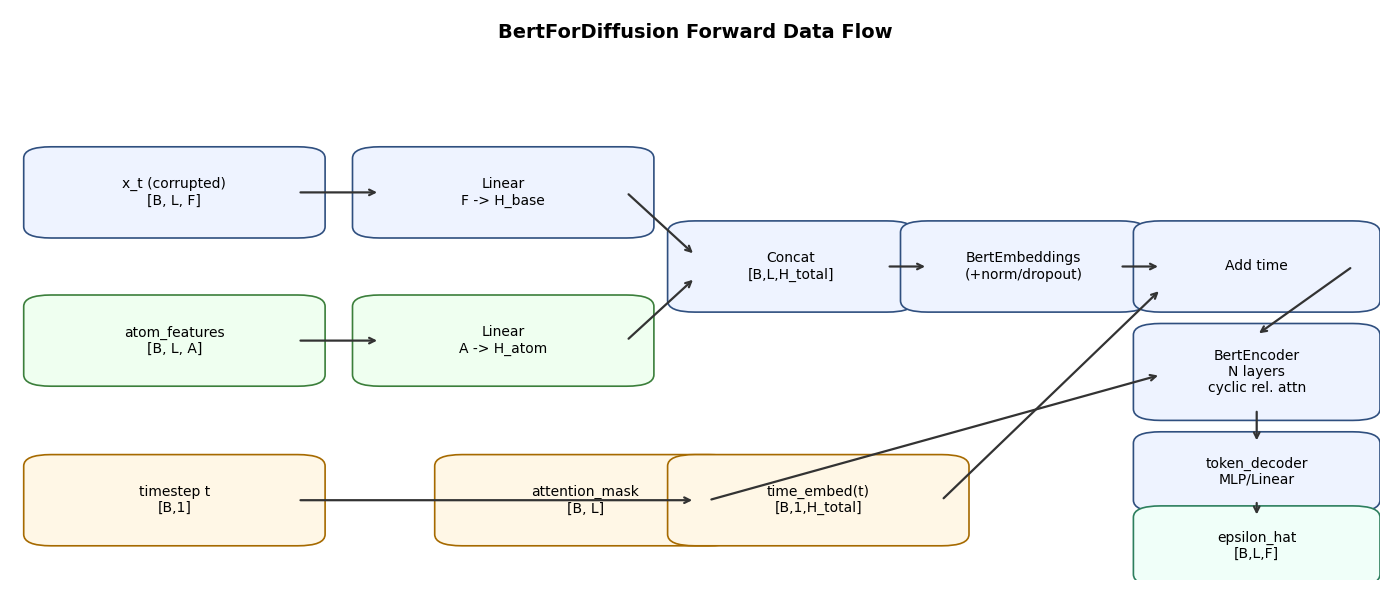

In [17]:
def draw_box(ax, xy, w, h, text, fc="#EEF3FF", ec="#2F4F7F", fontsize=10):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def arrow(ax, x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=1.6, color="#333333"),
    )


fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Inputs
x_t = (0.03, 0.62)
atm = (0.03, 0.36)
t_in = (0.03, 0.08)
mask = (0.33, 0.08)

draw_box(ax, x_t, 0.18, 0.12, "x_t (corrupted)\n[B, L, F]")
draw_box(ax, atm, 0.18, 0.12, "atom_features\n[B, L, A]", fc="#EFFFF0", ec="#3B7F3B")
draw_box(ax, t_in, 0.18, 0.12, "timestep t\n[B,1]", fc="#FFF7E6", ec="#A66A00")
draw_box(ax, mask, 0.18, 0.12, "attention_mask\n[B, L]", fc="#FFF7E6", ec="#A66A00")

# Projections
proj_x = (0.27, 0.62)
proj_a = (0.27, 0.36)
concat = (0.50, 0.49)
emb = (0.67, 0.49)
temb = (0.50, 0.08)
add_time = (0.84, 0.49)
encoder = (0.84, 0.30)
dec = (0.84, 0.14)
out = (0.84, 0.01)


draw_box(ax, proj_x, 0.18, 0.12, "Linear\nF -> H_base")
draw_box(ax, proj_a, 0.18, 0.12, "Linear\nA -> H_atom", fc="#EFFFF0", ec="#3B7F3B")
draw_box(ax, concat, 0.14, 0.12, "Concat\n[B,L,H_total]")
draw_box(ax, emb, 0.14, 0.12, "BertEmbeddings\n(+norm/dropout)")
draw_box(ax, temb, 0.18, 0.12, "time_embed(t)\n[B,1,H_total]", fc="#FFF7E6", ec="#A66A00")
draw_box(ax, add_time, 0.14, 0.12, "Add time")
draw_box(ax, encoder, 0.14, 0.13, "BertEncoder\nN layers\ncyclic rel. attn")
draw_box(ax, dec, 0.14, 0.10, "token_decoder\nMLP/Linear")
draw_box(ax, out, 0.14, 0.10, "epsilon_hat\n[B,L,F]", fc="#F0FFF9", ec="#2D7F5E")

# Arrows
arrow(ax, x_t[0] + 0.18, x_t[1] + 0.06, proj_x[0], proj_x[1] + 0.06)
arrow(ax, atm[0] + 0.18, atm[1] + 0.06, proj_a[0], proj_a[1] + 0.06)
arrow(ax, proj_x[0] + 0.18, proj_x[1] + 0.06, concat[0], concat[1] + 0.08)
arrow(ax, proj_a[0] + 0.18, proj_a[1] + 0.06, concat[0], concat[1] + 0.04)
arrow(ax, concat[0] + 0.14, concat[1] + 0.06, emb[0], emb[1] + 0.06)
arrow(ax, emb[0] + 0.14, emb[1] + 0.06, add_time[0], add_time[1] + 0.06)
arrow(ax, t_in[0] + 0.18, t_in[1] + 0.06, temb[0], temb[1] + 0.06)
arrow(ax, temb[0] + 0.18, temb[1] + 0.06, add_time[0], add_time[1] + 0.02)
arrow(ax, add_time[0] + 0.14, add_time[1] + 0.06, encoder[0] + 0.07, encoder[1] + 0.13)
arrow(ax, encoder[0] + 0.07, encoder[1], dec[0] + 0.07, dec[1] + 0.10)
arrow(ax, dec[0] + 0.07, dec[1], out[0] + 0.07, out[1] + 0.10)
arrow(ax, mask[0] + 0.18, mask[1] + 0.06, encoder[0], encoder[1] + 0.06)

ax.text(0.50, 0.96, "BertForDiffusion Forward Data Flow", ha="center", va="center", fontsize=14, fontweight="bold")

fig.tight_layout()

diagram_path = Path("assets/model_forward_architecture.png")
fig.savefig(diagram_path, dpi=200, bbox_inches="tight")
print("Saved diagram:", diagram_path)
plt.show()



## 13) End-to-end tensor flow table (quick reference)

This final table summarizes the main tensors in order.



In [18]:
flow_rows = [
    ("inputs", tuple(inputs.shape), "Noised internal coordinates x_t"),
    ("inputs_upscaled", tuple(inputs_upscaled.shape), "Linear projection of IC features"),
    ("atom_features_upscaled", None if atom_features_upscaled is None else tuple(atom_features_upscaled.shape), "Projected atom conditioning"),
    ("inputs_concat", tuple(inputs_concat.shape), "Concatenated token embeddings"),
    ("embeddings_out", tuple(embeddings_out.shape), "Post embedding block"),
    ("time_encoded", tuple(time_encoded.shape), "Broadcast time embedding"),
    ("inputs_with_time", tuple(inputs_with_time.shape), "Embeddings + time"),
    ("sequence_output", tuple(sequence_output.shape), "BERT encoder output"),
    ("predicted_noise", tuple(direct_pred_noise.shape), "Decoder output epsilon_hat"),
]

flow_df = pd.DataFrame(flow_rows, columns=["tensor", "shape", "meaning"])
display(flow_df)



,tensor,shape,meaning
0,inputs,"(4, 18, 12)",Noised internal coordinates x_t
1,inputs_upscaled,"(4, 18, 256)",Linear projection of IC features
2,atom_features_upscaled,"(4, 18, 128)",Projected atom conditioning
3,inputs_concat,"(4, 18, 384)",Concatenated token embeddings
4,embeddings_out,"(4, 18, 384)",Post embedding block
5,time_encoded,"(4, 1, 384)",Broadcast time embedding
6,inputs_with_time,"(4, 18, 384)",Embeddings + time
7,sequence_output,"(4, 18, 384)",BERT encoder output
8,predicted_noise,"(4, 18, 12)",Decoder output epsilon_hat
